Train shape: (8101, 98)
Test shape: (2026, 97)

Churn distribution:
churn
0    0.839279
1    0.160721
Name: proportion, dtype: float64

Top correlations:
churn                          1.000000
unresolved_complaint_count     0.494274
balance_decline_percentage     0.455938
complaint_resolution_time      0.448285
last_campaign_response_days    0.404755
emi_payment_delay_count        0.403164
service_request_count          0.392190
last_contacted_days            0.383718
retention_offer_received       0.371955
last_login_days                0.342650
Name: churn, dtype: float64
[LightGBM] [Info] Number of positive: 1041, number of negative: 5439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8517
[LightGBM] [Info] Number of data points in the train set: 6480, number of used features: 

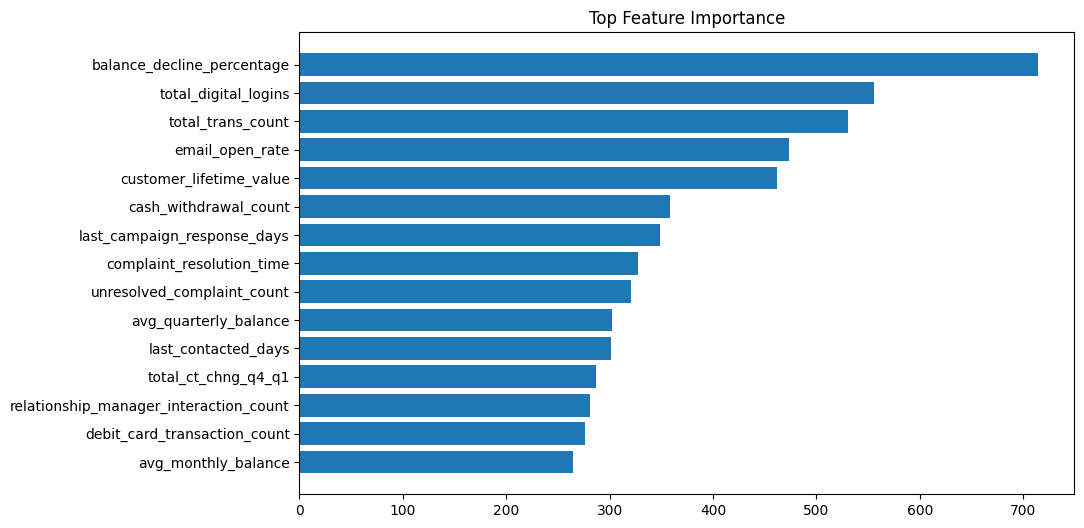


✅ FINAL FILE CREATED: predictions.csv


In [59]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import OrdinalEncoder

from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

# =========================
# 2. LOAD DATA
# =========================
train = pd.read_csv("ChurnZero_dataset_v1.csv")
test = pd.read_csv("ChurnZero_test_v1.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

# =========================
# 3. SPLIT DATA
# =========================
X = train.drop("churn", axis=1)
y = train["churn"]

id_col = "customer_id" if "customer_id" in test.columns else None

# =========================
# 4. REAL LEAKAGE CHECK (STRONG)
# =========================
print("\nChurn distribution:")
print(y.value_counts(normalize=True))

# Check high correlation (numeric only)
print("\nTop correlations:")
print(train.corr(numeric_only=True)["churn"].sort_values(ascending=False).head(10))

# =========================
# 5. ALIGN COLUMNS
# =========================
test = test[X.columns]

# =========================
# 6. SAFE ENCODING (BEST METHOD - NO LEAKAGE)
# =========================
cat_cols = X.select_dtypes(include=["object"]).columns

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X[cat_cols] = X[cat_cols].astype(str)
test[cat_cols] = test[cat_cols].astype(str)

X[cat_cols] = encoder.fit_transform(X[cat_cols])
test[cat_cols] = encoder.transform(test[cat_cols])

# =========================
# 7. TRAIN / VALID SPLIT
# =========================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 8. MODEL TRAINING
# =========================
model = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 9. VALIDATION
# =========================
val_probs = model.predict_proba(X_val)[:, 1]

threshold = 0.35
val_preds = (val_probs > threshold).astype(int)

print("\n===== MODEL PERFORMANCE =====")
print("ROC-AUC:", roc_auc_score(y_val, val_probs))
print("Precision:", precision_score(y_val, val_preds))
print("Recall:", recall_score(y_val, val_preds))
print("F1 Score:", f1_score(y_val, val_preds))

print("\nClassification Report:\n")
print(classification_report(y_val, val_preds))

# =========================
# 10. FEATURE IMPORTANCE
# =========================
import matplotlib.pyplot as plt

fi = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(fi["feature"][:15][::-1], fi["importance"][:15][::-1])
plt.title("Top Feature Importance")
plt.show()

# =========================
# 11. TEST PREDICTION
# =========================
test_probs = model.predict_proba(test)[:, 1]
test_preds = (test_probs > threshold).astype(int)

# =========================
# 12. SUBMISSION
# =========================
submission = pd.DataFrame()

if id_col:
    submission["customer_id"] = test[id_col]

submission["churn_prediction"] = test_preds
submission["churn_probability"] = test_probs

submission.to_csv("predictions.csv", index=False)

print("\n✅ FINAL FILE CREATED: predictions.csv")